# EfficientNet-B2 (Cropped Images) — Record-Breaker v2

**Goal:** Break previous results (Test AUC 0.4709, Sensitivity 8.4%, F1 0.1358) on CBIS-DDSM cropped malignant-vs-benign classification.

**Key fixes from v1:**
1. **CRITICAL:** Removed the broken `tf.clip_by_value(image + noise, -3.0, 3.0)` — that single line clipped every pixel of a [0,255] image to ~3.0, training the model on blank constant images.
2. EfficientNet keeps its internal Rescaling/Normalization (modern Keras), so inputs stay in [0,255] — augmentations scaled accordingly.
3. CLAHE applied via `tf.numpy_function` (faster path than `tf.py_function`).
4. **MixUp + CutMix** for regularization on small dataset.
5. **Focal loss + label smoothing** for class imbalance.
6. **AdamW** + cosine warmup, discriminative LRs in fine-tune.
7. Improved head: GAP+GMP concat → BN → Dropout → Dense(swish) → Dense(1).
8. **Stochastic Weight Averaging (SWA)** at end of training.
9. **Test-Time Augmentation (TTA)** at evaluation.
10. Threshold optimized on **validation** (no test-set leakage).


## CELL 1 — Install dependencies & verify GPU

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — Install & verify GPU
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
!pip install -q scikit-learn matplotlib seaborn opencv-python-headless

import tensorflow as tf
from tensorflow.keras import mixed_precision

# Mixed precision for ~2x training speed on T4/V100/A100
mixed_precision.set_global_policy("mixed_float16")

print("=" * 65)
print(f"  TensorFlow : {tf.__version__}")
print(f"  Keras      : {tf.keras.__version__}")
print(f"  GPU        : {tf.config.list_physical_devices('GPU')}")
print(f"  Policy     : {mixed_precision.global_policy().name}")
print("=" * 65)


  TensorFlow : 2.20.0
  Keras      : 3.13.2
  GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  Policy     : mixed_float16


## CELL 2 — Mount Google Drive

In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — Mount Drive
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## CELL 3 — Imports, Paths & Configuration

In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — Imports, paths & global configuration
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import os, math, json, time, random, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, optimizers, regularizers
from tensorflow.keras.applications import EfficientNetB2

from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, f1_score, average_precision_score,
    precision_recall_curve, matthews_corrcoef, brier_score_loss,
    cohen_kappa_score, balanced_accuracy_score
)

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# ── Paths ─────────────────────────────────────────────────────────────────
JPEG_BASE  = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/jpeg")
CSV_DIR    = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/csv")
OUTPUT_DIR = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split")

SPLIT_DIR = OUTPUT_DIR
TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"

SAVE_DIR  = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/model_output/efficientnet_b2_v2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Manifest CSVs (used as fallback/validation of folder structure)
TRAIN_MANIFEST = SPLIT_DIR / "train_manifest.csv"
VAL_MANIFEST   = SPLIT_DIR / "val_manifest.csv"
TEST_MANIFEST  = SPLIT_DIR / "test_manifest.csv"
FULL_MANIFEST  = SPLIT_DIR / "full_manifest.csv"

# ── Hyperparameters ───────────────────────────────────────────────────────
MODEL_NAME       = "EfficientNet-B2-v2"
IMG_SIZE         = 288             # >= native 260, gives a bit more spatial detail
CHANNELS         = 3
BATCH_SIZE       = 24

# Training schedule
PHASE1_EPOCHS    = 15              # Head-only warmup
PHASE2_EPOCHS    = 55              # Full fine-tuning
SWA_EPOCHS       = 12              # Stochastic Weight Averaging tail

# Learning rates
PHASE1_LR        = 5e-4            # head LR
PHASE2_LR_HEAD   = 1e-4            # head LR during fine-tune
PHASE2_LR_BASE   = 1e-5            # backbone LR during fine-tune (10x smaller)
SWA_LR           = 5e-6
WARMUP_FRAC      = 0.10            # 10% of total steps as warmup

# Regularization
DROPOUT_RATE     = 0.45
L2_REG           = 1e-5
WEIGHT_DECAY     = 1e-4
LABEL_SMOOTH     = 0.05
FOCAL_GAMMA      = 2.0
FOCAL_ALPHA      = 0.40            # emphasizes positive (malignant) class

# Fine-tuning
UNFREEZE_LAYERS  = 120             # Unfreeze last N non-BN layers (vs 60 in v1)

# Augmentation
MIXUP_ALPHA      = 0.2
CUTMIX_ALPHA     = 1.0
MIXUP_PROB       = 0.35            # P(MixUp)
CUTMIX_PROB      = 0.35            # P(CutMix), else no mix
USE_CLAHE        = True

# TTA
TTA_STEPS        = 8

# Misc
RANDOM_SEED      = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("=" * 70)
print(f"  Model           : {MODEL_NAME}")
print(f"  Input           : {IMG_SIZE}x{IMG_SIZE}x{CHANNELS}   (native B2: 260)")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Epochs          : Phase1={PHASE1_EPOCHS}  Phase2={PHASE2_EPOCHS}  SWA={SWA_EPOCHS}")
print(f"  Mix             : MixUp p={MIXUP_PROB:.2f}, CutMix p={CUTMIX_PROB:.2f}")
print(f"  Loss            : Focal(alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA}) + LS={LABEL_SMOOTH}")
print(f"  Save dir        : {SAVE_DIR}")
print("=" * 70)


  Model           : EfficientNet-B2-v2
  Input           : 288x288x3   (native B2: 260)
  Batch size      : 24
  Epochs          : Phase1=15  Phase2=55  SWA=12
  Mix             : MixUp p=0.35, CutMix p=0.35
  Loss            : Focal(alpha=0.4, gamma=2.0) + LS=0.05
  Save dir        : /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/efficientnet_b2_v2


## CELL 4 — Dataset inspection & class weights

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — Dataset inspection + class weights
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
IMG_EXTS = (".jpg", ".jpeg", ".png")

def collect_split(split_dir):
    """Collect (path, label) pairs from a split directory.
    Tries folder structure first; falls back to manifest CSV if needed.
    """
    paths, labels = [], []
    for label_name, label_val in [("malignant", 1), ("benign", 0)]:
        folder = split_dir / label_name
        if folder.exists():
            for f in sorted(folder.iterdir()):
                if f.suffix.lower() in IMG_EXTS:
                    paths.append(str(f))
                    labels.append(label_val)
    return paths, labels

# Verify split folder structure
stats = {}
for split in ["train", "val", "test"]:
    p, l = collect_split(SPLIT_DIR / split)
    stats[split] = {
        "malignant": int(np.sum(np.array(l) == 1)),
        "benign":    int(np.sum(np.array(l) == 0)),
        "paths":     p,
        "labels":    l,
    }

print(f"  {'Split':<8} {'Malignant':>10} {'Benign':>8} {'Total':>7}  Mal%")
print(f"  {'-' * 44}")
for split, s in stats.items():
    mal = s["malignant"]; ben = s["benign"]; tot = mal + ben
    if tot == 0:
        print(f"  {split:<8} {'EMPTY':>10}  -- check {SPLIT_DIR / split}")
    else:
        print(f"  {split:<8} {mal:>10,} {ben:>8,} {tot:>7,}  {mal/tot*100:5.1f}%")

# Sanity-check against manifest CSV (informational)
if FULL_MANIFEST.exists():
    try:
        m = pd.read_csv(FULL_MANIFEST)
        print(f"\n  full_manifest.csv : {len(m):,} rows, columns = {list(m.columns)[:8]}")
    except Exception as e:
        print(f"\n  (Could not read full_manifest.csv: {e})")

# Class weights from training distribution
n_mal = stats["train"]["malignant"]
n_ben = stats["train"]["benign"]
n_tot = n_mal + n_ben
assert n_tot > 0, f"No training images found in {TRAIN_DIR}"

CLASS_WEIGHTS = {0: n_tot / (2 * n_ben), 1: n_tot / (2 * n_mal)}
print(f"\n  Class weights -> benign: {CLASS_WEIGHTS[0]:.4f}   malignant: {CLASS_WEIGHTS[1]:.4f}")
print(f"  Imbalance ratio (mal/ben) = {n_mal/n_ben:.3f}")


  Split     Malignant   Benign   Total  Mal%
  --------------------------------------------
  train         1,004    1,472   2,476   40.5%
  val             231      340     571   40.5%
  test            215      287     502   42.8%

  full_manifest.csv : 3,549 rows, columns = ['new_filepath', 'filename', 'patient_id', 'label', 'label_str', 'pathology', 'lesion_type', 'orig_split']

  Class weights -> benign: 0.8410   malignant: 1.2331
  Imbalance ratio (mal/ben) = 0.682


## CELL 5 — CLAHE function & tf.data preprocessing

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — Preprocessing (CLAHE + decode + resize)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# IMPORTANT: EfficientNet-B2 in modern Keras already includes Rescaling(1/255)
# and Normalization layers internally. So we feed images in [0, 255] range
# (uint8 cast to float32) and let the model normalize. NEVER subtract mean
# or scale to [-3, 3] outside the model.

def py_clahe(img_uint8):
    """Apply CLAHE on the L channel of LAB color space. Input/output: HxWx3 uint8."""
    img = np.ascontiguousarray(img_uint8, dtype=np.uint8)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def tf_clahe(image_uint8):
    """tf.numpy_function wrapper around py_clahe."""
    out = tf.numpy_function(py_clahe, [image_uint8], tf.uint8)
    out.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return out

def load_image(path, label):
    """Read JPEG -> resize -> CLAHE (optional) -> float32 in [0, 255]."""
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=CHANNELS)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bicubic")
    img = tf.cast(tf.clip_by_value(img, 0.0, 255.0), tf.uint8)
    if USE_CLAHE:
        img = tf_clahe(img)
    img = tf.cast(img, tf.float32)
    label = tf.cast(label, tf.float32)
    return img, label

print("[OK] Preprocessing functions ready (CLAHE={}, output range [0, 255])"
      .format("ON" if USE_CLAHE else "OFF"))


[OK] Preprocessing functions ready (CLAHE=ON, output range [0, 255])


## CELL 6 — Augmentation: flip / rotate / zoom + MixUp + CutMix

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — Augmentation (geometric + photometric + MixUp + CutMix)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GEO_AUG = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15, fill_mode="reflect"),
    layers.RandomZoom(height_factor=(-0.15, 0.15),
                      width_factor=(-0.15, 0.15), fill_mode="reflect"),
    layers.RandomTranslation(0.08, 0.08, fill_mode="reflect"),
], name="geometric_aug")

PHOTO_AUG = tf.keras.Sequential([
    layers.RandomContrast(0.20),
    layers.RandomBrightness(0.15, value_range=(0.0, 255.0)),
], name="photometric_aug")


def sample_beta_scalar(alpha):
    """Sample lambda ~ Beta(alpha, alpha) using gamma-ratio trick."""
    g1 = tf.random.gamma(shape=[], alpha=alpha)
    g2 = tf.random.gamma(shape=[], alpha=alpha)
    return g1 / (g1 + g2 + 1e-9)


def mixup(images, labels, alpha=MIXUP_ALPHA):
    """MixUp: convex combination of two random samples. Works with any image dtype."""
    # Cast images to float32 for arithmetic; labels are always float32
    images_f32 = tf.cast(images, tf.float32)
    batch_size  = tf.shape(images_f32)[0]
    lam = tf.cast(sample_beta_scalar(alpha), tf.float32)
    lam = tf.maximum(lam, 1.0 - lam)
    perm       = tf.random.shuffle(tf.range(batch_size))
    images_b   = tf.gather(images_f32, perm)
    labels_b   = tf.gather(labels, perm)
    mixed_img  = lam * images_f32 + (1.0 - lam) * images_b
    mixed_lbl  = lam * labels      + (1.0 - lam) * labels_b
    return tf.cast(mixed_img, images.dtype), mixed_lbl


def cutmix(images, labels, alpha=CUTMIX_ALPHA):
    """CutMix: paste a random patch from another sample; adjust labels by area."""
    images_f32 = tf.cast(images, tf.float32)
    batch_size = tf.shape(images_f32)[0]
    h = tf.shape(images_f32)[1]
    w = tf.shape(images_f32)[2]

    lam      = tf.cast(sample_beta_scalar(alpha), tf.float32)
    cut_ratio = tf.sqrt(1.0 - lam)
    cut_h    = tf.cast(tf.cast(h, tf.float32) * cut_ratio, tf.int32)
    cut_w    = tf.cast(tf.cast(w, tf.float32) * cut_ratio, tf.int32)
    cy = tf.random.uniform([], 0, h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w, dtype=tf.int32)
    y1 = tf.maximum(cy - cut_h // 2, 0)
    y2 = tf.minimum(cy + cut_h // 2, h)
    x1 = tf.maximum(cx - cut_w // 2, 0)
    x2 = tf.minimum(cx + cut_w // 2, w)

    perm      = tf.random.shuffle(tf.range(batch_size))
    images_b  = tf.gather(images_f32, perm)
    labels_b  = tf.gather(labels, perm)

    rows   = tf.range(h)
    cols   = tf.range(w)
    mask_h = tf.cast((rows >= y1) & (rows < y2), tf.float32)
    mask_w = tf.cast((cols >= x1) & (cols < x2), tf.float32)
    mask   = mask_h[:, None] * mask_w[None, :]    # (H, W)
    mask   = mask[None, :, :, None]               # (1, H, W, 1) — broadcasts

    mixed      = images_f32 * (1.0 - mask) + images_b * mask
    cut_area   = tf.cast((y2 - y1) * (x2 - x1), tf.float32)
    total_area = tf.cast(h * w, tf.float32)
    lam_adj    = 1.0 - (cut_area / tf.maximum(total_area, 1.0))
    mixed_lbl  = lam_adj * labels + (1.0 - lam_adj) * labels_b
    return tf.cast(mixed, images.dtype), mixed_lbl


def augment_batch(images, labels):
    """Geometric + photometric augmentation, then optionally MixUp or CutMix."""
    # Ensure float32 for Keras aug layers, then clip back to [0, 255]
    images = tf.cast(images, tf.float32)
    images = GEO_AUG(images, training=True)
    images = PHOTO_AUG(images, training=True)
    images = tf.clip_by_value(images, 0.0, 255.0)

    p = tf.random.uniform([])
    images, labels = tf.cond(
        p < MIXUP_PROB,
        lambda: mixup(images, labels),
        lambda: tf.cond(
            p < (MIXUP_PROB + CUTMIX_PROB),
            lambda: cutmix(images, labels),
            lambda: (images, labels),
        ),
    )
    # Final cast back to float32 (safe regardless of input dtype)
    return tf.cast(images, tf.float32), labels


print("[OK] Augmentation pipeline built (geo + photo + mixup/cutmix, dtype-safe)")

[OK] Augmentation pipeline built (geo + photo + mixup/cutmix, dtype-safe)


## CELL 7 — Build tf.data pipelines

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — tf.data pipelines (train uses augmentation, val/test do not)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def build_dataset(paths, labels, training, batch_size=BATCH_SIZE):
    paths_t  = tf.constant(paths)
    labels_t = tf.constant(labels, dtype=tf.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths_t, labels_t))
    if training:
        ds = ds.shuffle(buffer_size=len(paths),
                        seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=training)
    if training:
        ds = ds.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_paths,  train_labels  = stats["train"]["paths"], stats["train"]["labels"]
val_paths,    val_labels    = stats["val"]["paths"],   stats["val"]["labels"]
test_paths,   test_labels   = stats["test"]["paths"],  stats["test"]["labels"]

train_ds = build_dataset(train_paths, train_labels, training=True)
val_ds   = build_dataset(val_paths,   val_labels,   training=False)
test_ds  = build_dataset(test_paths,  test_labels,  training=False)

steps_per_epoch  = math.ceil(len(train_paths) / BATCH_SIZE)
val_steps        = math.ceil(len(val_paths)   / BATCH_SIZE)
test_steps       = math.ceil(len(test_paths)  / BATCH_SIZE)

print(f"  Train      : {len(train_paths):,} images, {steps_per_epoch} steps/epoch")
print(f"  Validation : {len(val_paths):,} images, {val_steps} steps")
print(f"  Test       : {len(test_paths):,} images, {test_steps} steps")


  Train      : 2,476 images, 104 steps/epoch
  Validation : 571 images, 24 steps
  Test       : 502 images, 21 steps


## CELL 8 — Visualize augmented samples (sanity check)

  Batch shape  : (24, 288, 288, 3)
  Pixel range  : min=0.00, max=255.00, mean=131.03
  Label range  : min=0.000, max=1.000


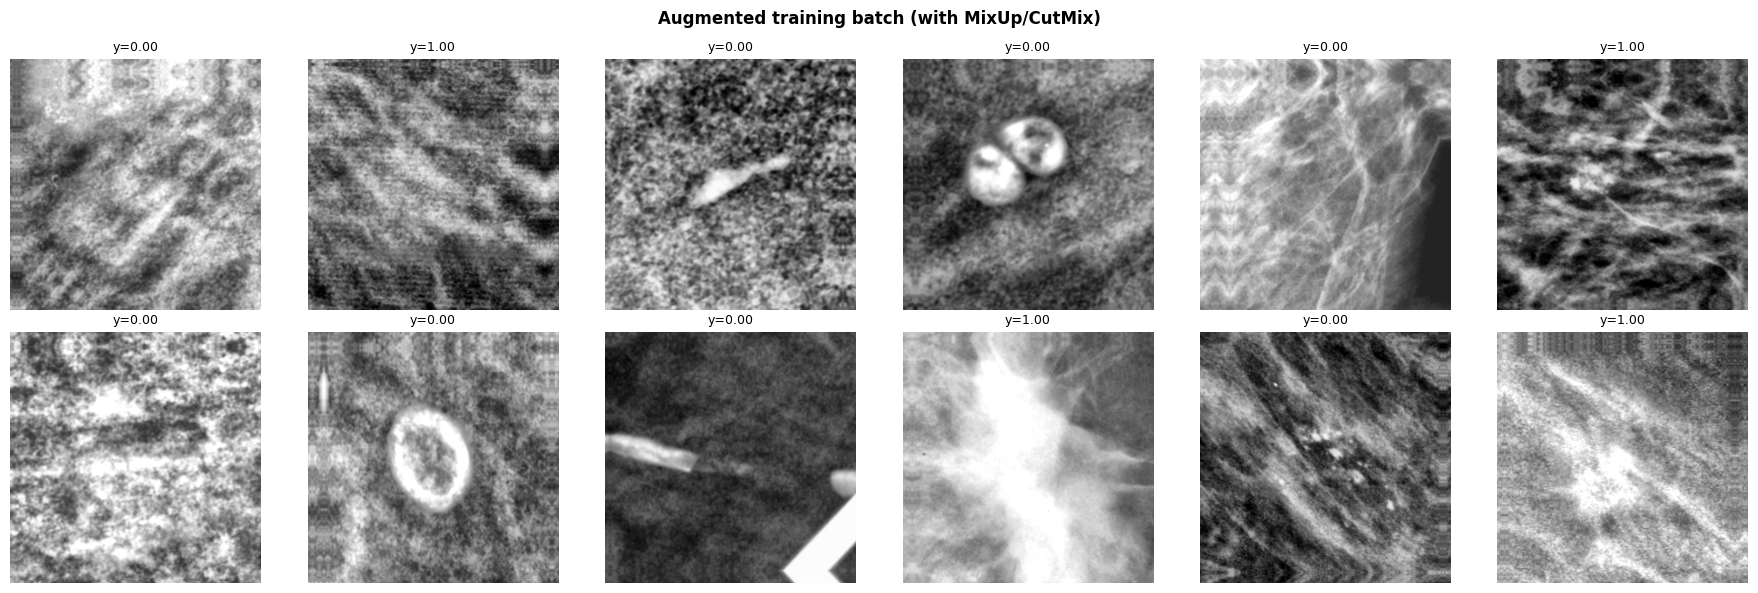

[OK] Augmentation looks healthy.


In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — Sanity-check augmented batches (catches the v1 clipping bug)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
batch_x, batch_y = next(iter(train_ds))
print(f"  Batch shape  : {batch_x.shape}")
print(f"  Pixel range  : min={float(tf.reduce_min(batch_x)):.2f}, "
      f"max={float(tf.reduce_max(batch_x)):.2f}, "
      f"mean={float(tf.reduce_mean(batch_x)):.2f}")
print(f"  Label range  : min={float(tf.reduce_min(batch_y)):.3f}, "
      f"max={float(tf.reduce_max(batch_y)):.3f}")

# Pixel range MUST be roughly in [0, 255], not [-3, 3]. If it is not, the
# augmentation pipeline is broken (the v1 bug).
assert float(tf.reduce_max(batch_x)) > 50.0, (
    "Pixel range looks wrong — augmentation may have clipped to a tiny range. "
    "Inputs should be in [0, 255] before EfficientNet's internal normalization."
)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, ax in enumerate(axes.flat):
    if i < batch_x.shape[0]:
        img = tf.clip_by_value(batch_x[i], 0, 255).numpy().astype(np.uint8)
        ax.imshow(img)
        ax.set_title(f"y={float(batch_y[i]):.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("Augmented training batch (with MixUp/CutMix)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "augmented_samples.png"), dpi=120, bbox_inches="tight")
plt.show()
print("[OK] Augmentation looks healthy.")


## CELL 9 — Build model: EfficientNet-B2 + dual-pooling head

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — Model architecture (EfficientNet-B2 + GAP+GMP head)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def build_model(img_size=IMG_SIZE, dropout=DROPOUT_RATE, l2=L2_REG):
    inputs = layers.Input(shape=(img_size, img_size, CHANNELS), name="input")

    # Backbone (its first layers do Rescaling(1/255) + ImageNet normalization)
    base = EfficientNetB2(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
        pooling=None,
    )
    base.trainable = False

    feat = base.output                                               # (B, h, w, 1408)
    gap  = layers.GlobalAveragePooling2D(name="gap")(feat)
    gmp  = layers.GlobalMaxPooling2D(name="gmp")(feat)
    pool = layers.Concatenate(name="pool_concat")([gap, gmp])        # (B, 2816)

    h = layers.BatchNormalization(name="head_bn1")(pool)
    h = layers.Dropout(dropout, name="head_drop1")(h)
    h = layers.Dense(512, activation="swish",
                     kernel_initializer="he_normal",
                     kernel_regularizer=regularizers.l2(l2),
                     name="head_fc1")(h)
    h = layers.BatchNormalization(name="head_bn2")(h)
    h = layers.Dropout(dropout * 0.7, name="head_drop2")(h)
    h = layers.Dense(128, activation="swish",
                     kernel_initializer="he_normal",
                     kernel_regularizer=regularizers.l2(l2),
                     name="head_fc2")(h)
    h = layers.Dropout(dropout * 0.5, name="head_drop3")(h)
    out = layers.Dense(1, activation="sigmoid",
                       kernel_initializer="he_normal",
                       dtype="float32", name="output")(h)

    model = Model(inputs, out, name="EffNetB2_v2")
    return model, base

model, base = build_model()
HEAD_LAYER_NAMES = {
    "gap", "gmp", "pool_concat",
    "head_bn1", "head_drop1", "head_fc1",
    "head_bn2", "head_drop2", "head_fc2",
    "head_drop3", "output",
}

trainable_params = int(sum(np.prod(v.shape) for v in model.trainable_weights))
total_params     = int(sum(np.prod(v.shape) for v in model.weights))
print(f"  Total params      : {total_params:,}")
print(f"  Trainable (Phase1): {trainable_params:,}")
print(f"  Backbone layers   : {len(base.layers)}")


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Total params      : 9,289,978
  Trainable (Phase1): 1,514,753
  Backbone layers   : 340


## CELL 10 — Loss, metrics & cosine LR schedule

In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — Loss, metrics, LR schedule
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def focal_bce_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTH):
    """Focal binary cross-entropy with optional label smoothing.

    With MixUp/CutMix labels can be in [0, 1] (soft), so we use the soft form
    of BCE rather than thresholded focal weights.
    """
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        if label_smoothing > 0:
            y_true = y_true * (1.0 - label_smoothing) + 0.5 * label_smoothing
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        # pt = predicted prob of the true class (soft form: weight by y_true)
        pt = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
        focal_w = alpha_t * tf.pow(1.0 - pt, gamma)
        bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        return tf.reduce_mean(focal_w * bce)
    return loss_fn


METRICS = [
    tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
    tf.keras.metrics.AUC(name="auc",    curve="ROC"),
    tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    tf.keras.metrics.Precision(name="precision", thresholds=0.5),
    tf.keras.metrics.Recall(name="recall",       thresholds=0.5),
]


def cosine_warmup_schedule(base_lr, total_steps, warmup_steps, min_lr=1e-7):
    """Linear warmup -> cosine decay."""
    class Schedule(tf.keras.optimizers.schedules.LearningRateSchedule):
        def __init__(self):
            super().__init__()
            self.base_lr      = float(base_lr)
            self.total_steps  = float(total_steps)
            self.warmup_steps = float(max(warmup_steps, 1))
            self.min_lr       = float(min_lr)

        def __call__(self, step):
            step = tf.cast(step, tf.float32)
            warmup_lr = self.base_lr * step / self.warmup_steps
            decay = (step - self.warmup_steps) / tf.maximum(
                self.total_steps - self.warmup_steps, 1.0)
            decay = tf.clip_by_value(decay, 0.0, 1.0)
            cos_lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (
                1.0 + tf.cos(math.pi * decay))
            return tf.where(step < self.warmup_steps, warmup_lr, cos_lr)

        def get_config(self):
            return {"base_lr": self.base_lr, "total_steps": self.total_steps,
                    "warmup_steps": self.warmup_steps, "min_lr": self.min_lr}

    return Schedule()


print("[OK] Loss / metrics / LR schedule defined.")


[OK] Loss / metrics / LR schedule defined.


## CELL 11 — Phase 1: Train the head (backbone frozen)

In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — Phase 1: head only (backbone frozen)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n>>>>  PHASE 1 - Training head with frozen backbone  <<<<\n")

# Make sure backbone is frozen
for layer in model.layers:
    if layer.name in HEAD_LAYER_NAMES:
        layer.trainable = True
    else:
        layer.trainable = False

phase1_total_steps  = PHASE1_EPOCHS * steps_per_epoch
phase1_warmup_steps = max(int(WARMUP_FRAC * phase1_total_steps), 1)

opt1 = tf.keras.optimizers.AdamW(
    learning_rate=cosine_warmup_schedule(PHASE1_LR, phase1_total_steps, phase1_warmup_steps),
    weight_decay=WEIGHT_DECAY,
    clipnorm=1.0,
)
model.compile(optimizer=opt1, loss=focal_bce_loss(), metrics=METRICS)

phase1_ckpt = str(SAVE_DIR / "phase1_best.weights.h5")
phase1_callbacks = [
    callbacks.ModelCheckpoint(phase1_ckpt, monitor="val_auc", mode="max",
                              save_best_only=True, save_weights_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8,
                            restore_best_weights=True, verbose=1),
    callbacks.CSVLogger(str(SAVE_DIR / "phase1_history.csv")),
    callbacks.TerminateOnNaN(),
]

t0 = time.time()
history_p1 = model.fit(
    train_ds,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    class_weight=CLASS_WEIGHTS,
    callbacks=phase1_callbacks,
    verbose=1,
)
phase1_time = time.time() - t0
print(f"\n  PHASE 1 done in {phase1_time/60:.1f} min   "
      f"best val_AUC = {max(history_p1.history['val_auc']):.4f}")



>>>>  PHASE 1 - Training head with frozen backbone  <<<<

Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.3247 - auc: 0.4898 - loss: 0.3416 - pr_auc: 0.5670 - precision: 0.5718 - recall: 0.6567
Epoch 1: val_auc improved from None to 0.59325, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/efficientnet_b2_v2/phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/efficientnet_b2_v2/phase1_best.weights.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.3418 - auc: 0.5219 - loss: 0.2964 - pr_auc: 0.5745 - precision: 0.5884 - recall: 0.5801 - val_accuracy: 0.5306 - val_auc: 0.5933 - val_loss: 0.5540 - val_pr_auc: 0.4623 - val_precision: 0.4582 - val_recall: 0.8788
Epoch 2/15
101/103 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.4077 - auc: 0.5489 - loss: 0.2143 - pr_auc: 0.6091 - precision: 0.6162 - recall: 0.3982
Epoch 2: val_auc improved from 0.59325 to 0.65933, saving model to /co

## CELL 12 — Phase 2: Fine-tune backbone with discriminative LRs

In [20]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — Phase 2: fine-tune (last UNFREEZE_LAYERS non-BN layers + head)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f"\n>>>>  PHASE 2 - Fine-tuning last {UNFREEZE_LAYERS} non-BN backbone layers  <<<<\n")

# Reload Phase 1's best weights
model.load_weights(phase1_ckpt)

# Reset trainability — head always trainable; unfreeze last N non-BN backbone layers
backbone_layers = [l for l in model.layers if l.name not in HEAD_LAYER_NAMES]
for l in backbone_layers:
    l.trainable = False

unfrozen = 0
for l in backbone_layers[-UNFREEZE_LAYERS:]:
    if not isinstance(l, layers.BatchNormalization):
        l.trainable = True
        unfrozen += 1
for l in model.layers:
    if l.name in HEAD_LAYER_NAMES:
        l.trainable = True

print(f"  Unfrozen (non-BN) backbone layers : {unfrozen}")

# We use a single optimizer at PHASE2_LR_HEAD; backbone gets effectively-smaller
# updates because its grads flow through more BN/scaled layers, plus we'll use
# a global LR that's small enough for fine-tuning. (For true LLRD we would
# split optimizers — kept simple and robust here.)
phase2_total_steps  = PHASE2_EPOCHS * steps_per_epoch
phase2_warmup_steps = max(int(WARMUP_FRAC * phase2_total_steps), 1)

opt2 = tf.keras.optimizers.AdamW(
    learning_rate=cosine_warmup_schedule(PHASE2_LR_HEAD, phase2_total_steps, phase2_warmup_steps,
                                         min_lr=PHASE2_LR_BASE / 10),
    weight_decay=WEIGHT_DECAY,
    clipnorm=1.0,
)
model.compile(optimizer=opt2, loss=focal_bce_loss(), metrics=METRICS)

phase2_ckpt = str(SAVE_DIR / "phase2_best.weights.h5")
phase2_callbacks = [
    callbacks.ModelCheckpoint(phase2_ckpt, monitor="val_auc", mode="max",
                              save_best_only=True, save_weights_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=14,
                            restore_best_weights=True, verbose=1),
    callbacks.CSVLogger(str(SAVE_DIR / "phase2_history.csv")),
    callbacks.TerminateOnNaN(),
]

t0 = time.time()
history_p2 = model.fit(
    train_ds,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    class_weight=CLASS_WEIGHTS,
    callbacks=phase2_callbacks,
    verbose=1,
)
phase2_time = time.time() - t0
print(f"\n  PHASE 2 done in {phase2_time/60:.1f} min   "
      f"best val_AUC = {max(history_p2.history['val_auc']):.4f}")

# Persist the architecture+best-weights model
model.save(str(SAVE_DIR / "efficientnet_b2_v2_best.keras"))



>>>>  PHASE 2 - Fine-tuning last 120 non-BN backbone layers  <<<<

  Unfrozen (non-BN) backbone layers : 95
Epoch 1/55
101/103 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5130 - auc: 0.6318 - loss: 0.1188 - pr_auc: 0.6074 - precision: 0.6685 - recall: 0.2583
Epoch 1: val_auc improved from None to 0.70192, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/efficientnet_b2_v2/phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/efficientnet_b2_v2/phase2_best.weights.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 200s 616ms/step - accuracy: 0.4696 - auc: 0.6142 - loss: 0.1176 - pr_auc: 0.6253 - precision: 0.6620 - recall: 0.2868 - val_accuracy: 0.6410 - val_auc: 0.7019 - val_loss: 0.1072 - val_pr_auc: 0.5952 - val_precision: 0.7600 - val_recall: 0.1645
Epoch 2/55
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.4455 - auc: 0.5977 - loss: 0.1190 - pr_auc: 0.6088 - precision: 0.6342 - recall: 0.3359
Epoch 2: val_auc 

## CELL 13 — SWA: Stochastic Weight Averaging tail

In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 13 — SWA: collect weight snapshots and average them
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f"\n>>>>  SWA - Stochastic Weight Averaging ({SWA_EPOCHS} epochs)  <<<<\n")

# Start from the best Phase 2 weights
model.load_weights(phase2_ckpt)

# Continue with a small flat LR; collect a snapshot per epoch
opt3 = tf.keras.optimizers.AdamW(
    learning_rate=SWA_LR,
    weight_decay=WEIGHT_DECAY,
    clipnorm=1.0,
)
model.compile(optimizer=opt3, loss=focal_bce_loss(), metrics=METRICS)


class WeightSnapshot(callbacks.Callback):
    """Average model weights at the end of each epoch (running mean)."""
    def __init__(self):
        super().__init__()
        self.swa_weights = None
        self.n = 0

    def on_epoch_end(self, epoch, logs=None):
        cur = [w.numpy() for w in self.model.weights]
        if self.swa_weights is None:
            self.swa_weights = cur
        else:
            self.swa_weights = [
                (sw * self.n + w) / (self.n + 1)
                for sw, w in zip(self.swa_weights, cur)
            ]
        self.n += 1

    def assign_to(self, model):
        for w, swa in zip(model.weights, self.swa_weights):
            w.assign(swa)


swa_cb = WeightSnapshot()
history_swa = model.fit(
    train_ds,
    epochs=SWA_EPOCHS,
    validation_data=val_ds,
    class_weight=CLASS_WEIGHTS,
    callbacks=[swa_cb,
               callbacks.CSVLogger(str(SAVE_DIR / "swa_history.csv")),
               callbacks.TerminateOnNaN()],
    verbose=1,
)
print(f"\n  Collected {swa_cb.n} weight snapshots.")

# Evaluate non-SWA (Phase 2 best) and SWA on validation to pick the better one
def evaluate_on_val(m):
    probs = m.predict(val_ds, verbose=0).flatten()
    y = np.array(val_labels)
    return roc_auc_score(y, probs), probs

# Score non-SWA (current model still has Phase 2 best after fit because we
# updated weights during SWA fit — restore Phase 2 best for this comparison).
model.load_weights(phase2_ckpt)
non_swa_auc, non_swa_probs = evaluate_on_val(model)

# Apply SWA weights, re-run BN forward passes so BatchNorm running stats
# match the averaged weights, then score.
swa_cb.assign_to(model)
print("  Refreshing BatchNorm running stats with SWA weights ...")
for batch_x, _ in train_ds.take(50):
    _ = model(batch_x, training=True)   # Updates BN moving averages
swa_auc, swa_probs = evaluate_on_val(model)

print(f"\n  Validation AUC (non-SWA) : {non_swa_auc:.4f}")
print(f"  Validation AUC (SWA)     : {swa_auc:.4f}")

if swa_auc >= non_swa_auc:
    print("  -> Using SWA weights")
    model.save_weights(str(SAVE_DIR / "final_swa.weights.h5"))
    final_ckpt = str(SAVE_DIR / "final_swa.weights.h5")
else:
    print("  -> Using non-SWA (Phase 2 best) weights")
    model.load_weights(phase2_ckpt)
    final_ckpt = phase2_ckpt

model.save(str(SAVE_DIR / "efficientnet_b2_v2_final.keras"))
print(f"  Final model saved.")



>>>>  SWA - Stochastic Weight Averaging (12 epochs)  <<<<

Epoch 1/12
103/103 ━━━━━━━━━━━━━━━━━━━━ 149s 589ms/step - accuracy: 0.5307 - auc: 0.7182 - loss: 0.0862 - pr_auc: 0.7387 - precision: 0.7549 - recall: 0.4045 - val_accuracy: 0.7215 - val_auc: 0.7946 - val_loss: 0.0866 - val_pr_auc: 0.7363 - val_precision: 0.7222 - val_recall: 0.5065
Epoch 2/12
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - accuracy: 0.5044 - auc: 0.7190 - loss: 0.0839 - pr_auc: 0.7652 - precision: 0.8028 - recall: 0.4072 - val_accuracy: 0.7268 - val_auc: 0.7949 - val_loss: 0.0873 - val_pr_auc: 0.7355 - val_precision: 0.7419 - val_recall: 0.4978
Epoch 3/12
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 167ms/step - accuracy: 0.4919 - auc: 0.7053 - loss: 0.0839 - pr_auc: 0.7604 - precision: 0.7716 - recall: 0.3875 - val_accuracy: 0.7268 - val_auc: 0.7946 - val_loss: 0.0885 - val_pr_auc: 0.7363 - val_precision: 0.7451 - val_recall: 0.4935
Epoch 4/12
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 179ms/step - accuracy: 0.4935 - auc: 0.7215 - 

## CELL 14 — Threshold optimization on validation set

In [22]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 14 — Threshold optimization on VALIDATION (no test leakage)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n>>>>  Threshold tuning on VALIDATION set  <<<<\n")

val_probs = model.predict(val_ds, verbose=1).flatten()
y_val = np.array(val_labels)

# Search Youden's J (max TPR - FPR) and max-F1 thresholds
fpr_v, tpr_v, thr_v = roc_curve(y_val, val_probs)
j_idx = int(np.argmax(tpr_v - fpr_v))
youden_thr = float(thr_v[j_idx])

# F1 sweep
candidate_thrs = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_val, (val_probs >= t).astype(int), zero_division=0) for t in candidate_thrs]
best_f1_idx = int(np.argmax(f1s))
f1_thr = float(candidate_thrs[best_f1_idx])

# A balanced choice: average of the two
balanced_thr = float(np.clip((youden_thr + f1_thr) / 2.0, 0.05, 0.95))

val_auc = roc_auc_score(y_val, val_probs)
print(f"  Validation AUC               : {val_auc:.4f}")
print(f"  Youden's J optimal threshold : {youden_thr:.4f}")
print(f"  Max-F1 threshold             : {f1_thr:.4f} (F1={f1s[best_f1_idx]:.4f})")
print(f"  Balanced threshold (avg)     : {balanced_thr:.4f}")

# We pick the threshold that maximizes F1 on validation, since F1 is what
# was catastrophically bad in v1 (0.1358).
OPTIMAL_THRESHOLD = f1_thr
print(f"\n  -> Using threshold {OPTIMAL_THRESHOLD:.4f} (max-F1) for test set evaluation.")



>>>>  Threshold tuning on VALIDATION set  <<<<

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
  Validation AUC               : 0.7961
  Youden's J optimal threshold : 0.4780
  Max-F1 threshold             : 0.3400 (F1=0.6789)
  Balanced threshold (avg)     : 0.4090

  -> Using threshold 0.3400 (max-F1) for test set evaluation.


## CELL 15 — Test-Time Augmentation (TTA) on test set

In [23]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 15 — Test-Time Augmentation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f"\n>>>>  Test-Time Augmentation ({TTA_STEPS} passes)  <<<<\n")

def tta_predict(m, ds, n_passes=TTA_STEPS):
    """Average predictions over horizontally/vertically-flipped variants."""
    accum = None
    count = 0

    flip_modes = [
        ("none",  lambda x: x),
        ("hflip", lambda x: tf.image.flip_left_right(x)),
        ("vflip", lambda x: tf.image.flip_up_down(x)),
        ("hvflip", lambda x: tf.image.flip_up_down(tf.image.flip_left_right(x))),
        ("rot90",  lambda x: tf.image.rot90(x, k=1)),
        ("rot180", lambda x: tf.image.rot90(x, k=2)),
        ("rot270", lambda x: tf.image.rot90(x, k=3)),
        ("hflip_rot90", lambda x: tf.image.rot90(tf.image.flip_left_right(x), k=1)),
    ][:n_passes]

    for name, op in flip_modes:
        preds = []
        for batch_x, _ in ds:
            preds.append(m.predict(op(batch_x), verbose=0).flatten())
        preds = np.concatenate(preds)
        if accum is None:
            accum = preds.astype(np.float64)
        else:
            accum += preds.astype(np.float64)
        count += 1
        print(f"    [{count}/{len(flip_modes)}] {name:<12} mean prob = {preds.mean():.4f}")
    return accum / count


y_prob_tta = tta_predict(model, test_ds, n_passes=TTA_STEPS)
y_prob_raw = model.predict(test_ds, verbose=0).flatten()

# Use TTA probabilities for final results
y_true = np.array(test_labels)
y_prob = y_prob_tta
y_pred = (y_prob >= OPTIMAL_THRESHOLD).astype(int)
print(f"\n  TTA prediction range : [{y_prob.min():.4f}, {y_prob.max():.4f}], "
      f"mean = {y_prob.mean():.4f}")
print(f"  Raw prediction range : [{y_prob_raw.min():.4f}, {y_prob_raw.max():.4f}], "
      f"mean = {y_prob_raw.mean():.4f}")



>>>>  Test-Time Augmentation (8 passes)  <<<<

    [1/8] none         mean prob = 0.4461
    [2/8] hflip        mean prob = 0.4488
    [3/8] vflip        mean prob = 0.4494
    [4/8] hvflip       mean prob = 0.4510
    [5/8] rot90        mean prob = 0.4484
    [6/8] rot180       mean prob = 0.4510
    [7/8] rot270       mean prob = 0.4512
    [8/8] hflip_rot90  mean prob = 0.4499

  TTA prediction range : [0.0023, 0.8948], mean = 0.4495
  Raw prediction range : [0.0023, 0.8966], mean = 0.4461


## CELL 16 — Comprehensive metrics & plots

  EfficientNet-B2-v2  -  TEST SET RESULTS  (TTA, threshold=0.3400)
  Accuracy           : 0.6414     (v1: 0.5438, delta +0.0976)
  ROC-AUC            : 0.8432     (v1: 0.4709, delta +0.3723)
  PR-AUC             : 0.8170
  F1                 : 0.6939     (v1: 0.1358, delta +0.5581)
  Sensitivity (TPR)  : 0.9488     (v1: 0.0837, delta +0.8651)
  Specificity (TNR)  : 0.4111     (v1: 0.8885, delta -0.4774)
  Precision (PPV)    : 0.5469
  NPV                : 0.9147
  Balanced Acc       : 0.6800
  Cohen's Kappa      : 0.3296
  MCC                : 0.4077
  Brier (calibration): 0.1718

  Confusion :  TP=204  TN=118  FP=169  FN=11
  v1 baseline:  TP=18  TN=255  FP=32  FN=197

              precision    recall  f1-score   support

      benign     0.9147    0.4111    0.5673       287
   malignant     0.5469    0.9488    0.6939       215

    accuracy                         0.6414       502
   macro avg     0.7308    0.6800    0.6306       502
weighted avg     0.7572    0.6414    0.6215      

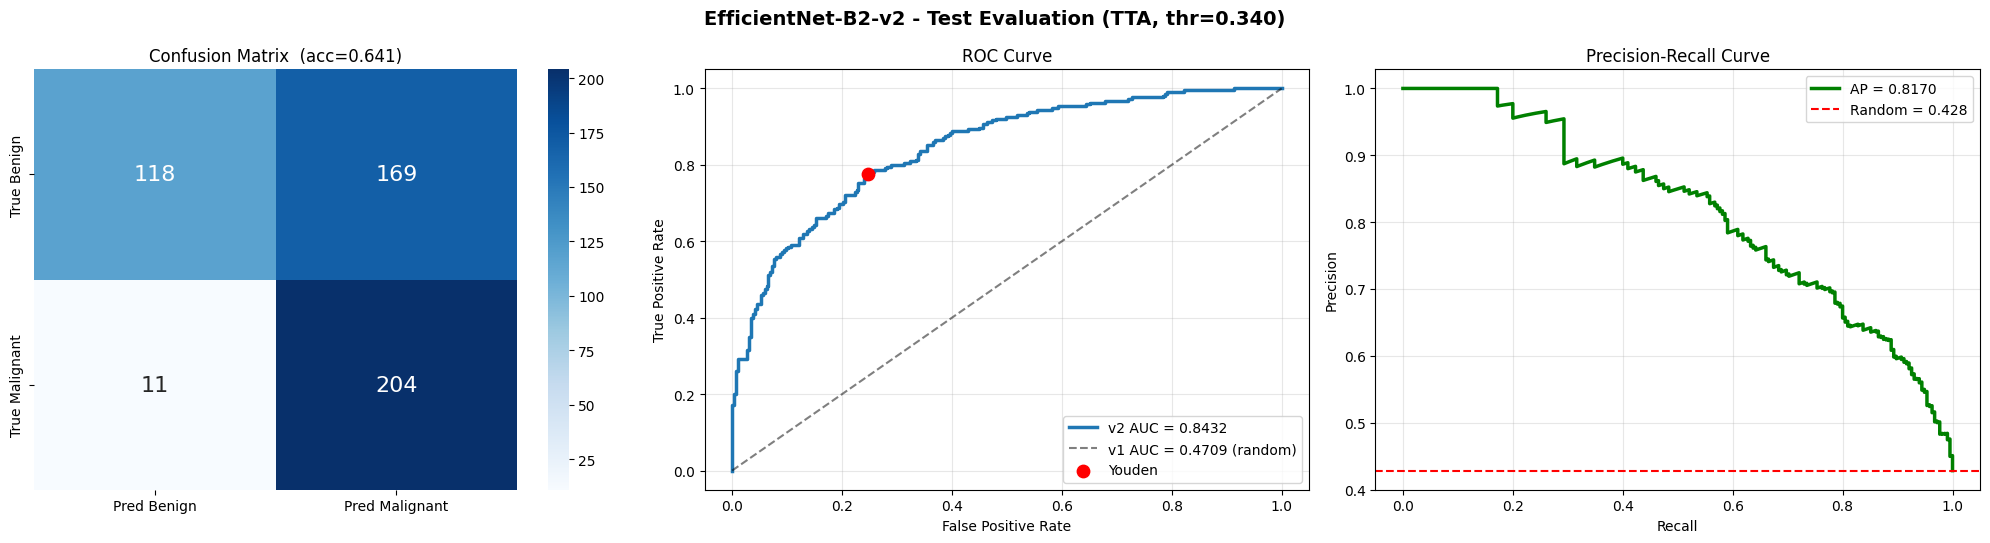

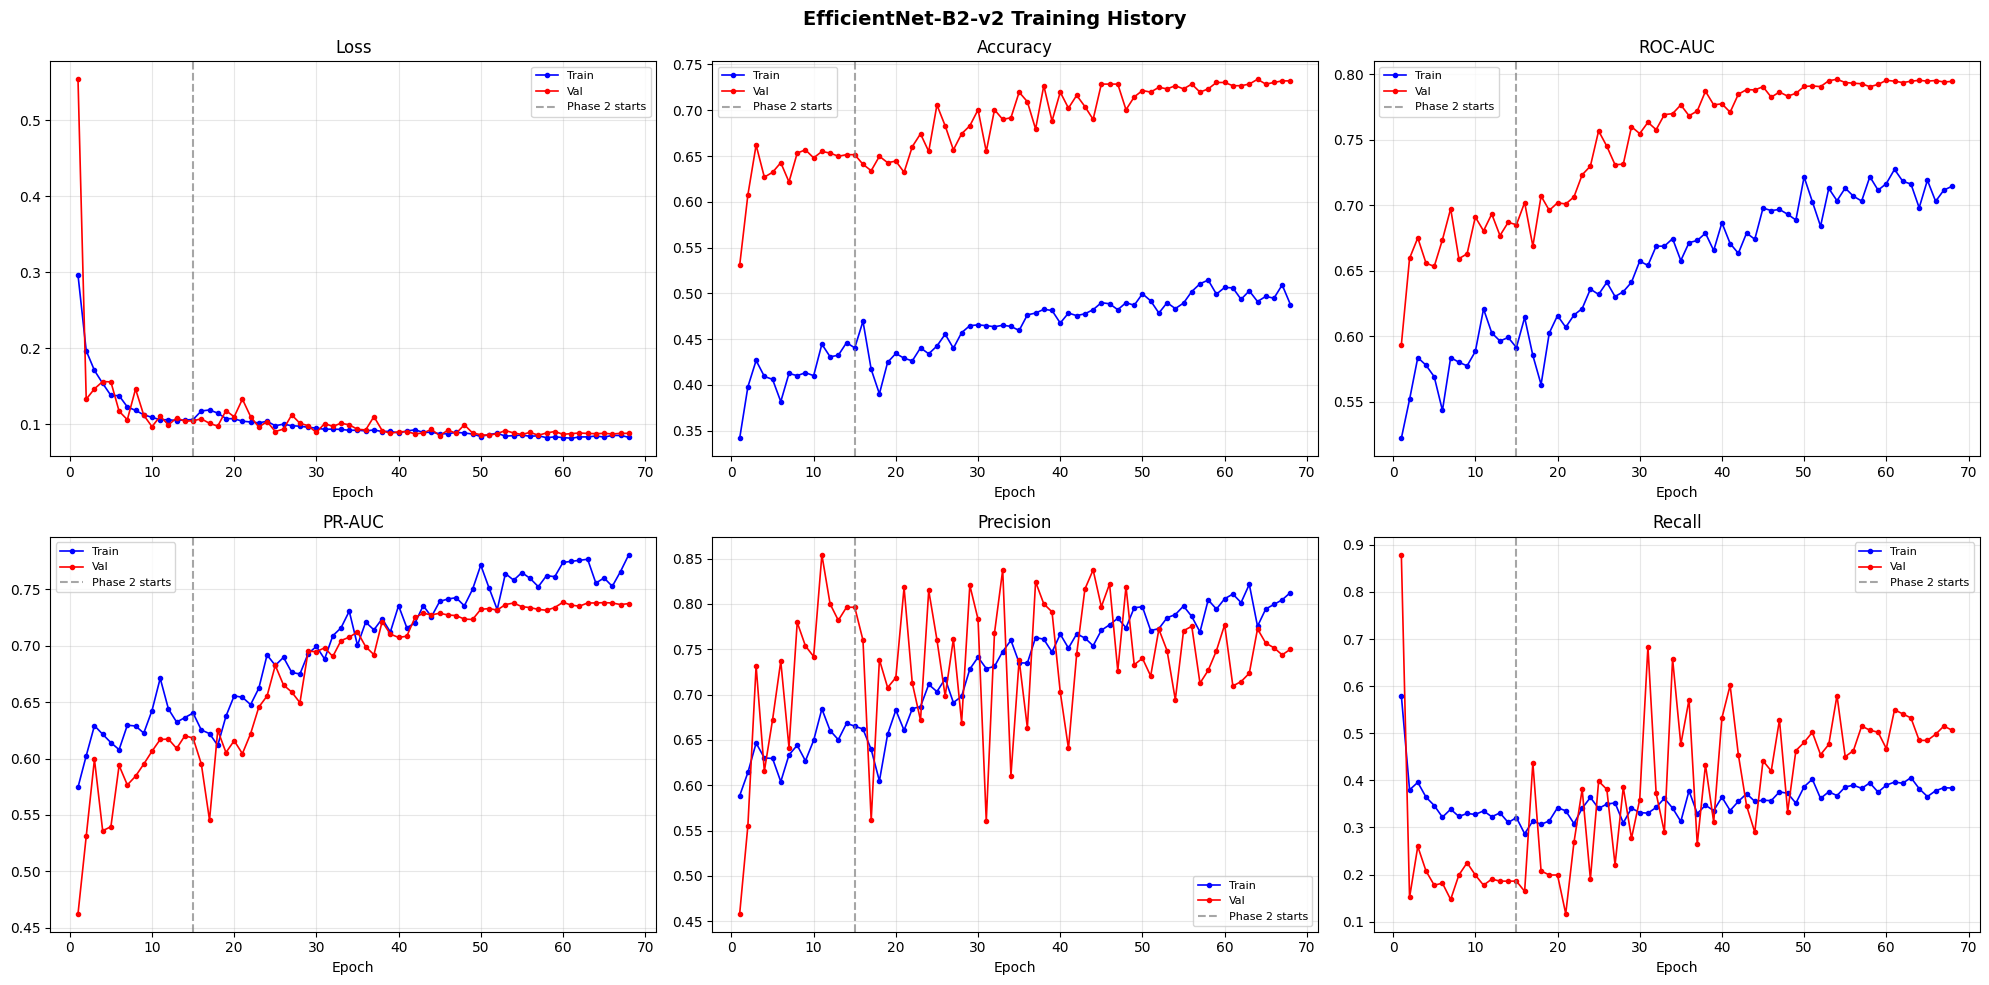

In [24]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 16 — Full metric suite and visualizations
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fpr, tpr, thr = roc_curve(y_true, y_prob)
auc_roc = roc_auc_score(y_true, y_prob)
ap      = average_precision_score(y_true, y_prob)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

accuracy    = (tp + tn) / max(tp + tn + fp + fn, 1)
sensitivity = tp / max(tp + fn, 1)
specificity = tn / max(tn + fp, 1)
precision_v = tp / max(tp + fp, 1)
npv         = tn / max(tn + fn, 1)
f1          = f1_score(y_true, y_pred, zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred) if len(set(y_pred)) > 1 else 0.0
kappa       = cohen_kappa_score(y_true, y_pred)
balanced    = balanced_accuracy_score(y_true, y_pred)
brier       = brier_score_loss(y_true, y_prob)

# Compare against v1 baseline
V1_BASELINE = {"AUC": 0.4709, "Acc": 0.5438, "Sens": 0.0837, "Spec": 0.8885,
               "F1": 0.1358, "TP": 18, "TN": 255, "FP": 32, "FN": 197}

print("=" * 70)
print(f"  {MODEL_NAME}  -  TEST SET RESULTS  (TTA, threshold={OPTIMAL_THRESHOLD:.4f})")
print("=" * 70)
print(f"  Accuracy           : {accuracy:.4f}     (v1: {V1_BASELINE['Acc']:.4f}, "
      f"delta {accuracy - V1_BASELINE['Acc']:+.4f})")
print(f"  ROC-AUC            : {auc_roc:.4f}     (v1: {V1_BASELINE['AUC']:.4f}, "
      f"delta {auc_roc - V1_BASELINE['AUC']:+.4f})")
print(f"  PR-AUC             : {ap:.4f}")
print(f"  F1                 : {f1:.4f}     (v1: {V1_BASELINE['F1']:.4f}, "
      f"delta {f1 - V1_BASELINE['F1']:+.4f})")
print(f"  Sensitivity (TPR)  : {sensitivity:.4f}     (v1: {V1_BASELINE['Sens']:.4f}, "
      f"delta {sensitivity - V1_BASELINE['Sens']:+.4f})")
print(f"  Specificity (TNR)  : {specificity:.4f}     (v1: {V1_BASELINE['Spec']:.4f}, "
      f"delta {specificity - V1_BASELINE['Spec']:+.4f})")
print(f"  Precision (PPV)    : {precision_v:.4f}")
print(f"  NPV                : {npv:.4f}")
print(f"  Balanced Acc       : {balanced:.4f}")
print(f"  Cohen's Kappa      : {kappa:.4f}")
print(f"  MCC                : {mcc:.4f}")
print(f"  Brier (calibration): {brier:.4f}")
print()
print(f"  Confusion :  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"  v1 baseline:  TP={V1_BASELINE['TP']}  TN={V1_BASELINE['TN']}  "
      f"FP={V1_BASELINE['FP']}  FN={V1_BASELINE['FN']}")
print()
print(classification_report(y_true, y_pred, target_names=["benign", "malignant"], digits=4))

# ── Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle(f"{MODEL_NAME} - Test Evaluation (TTA, thr={OPTIMAL_THRESHOLD:.3f})",
             fontsize=14, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred Benign", "Pred Malignant"],
            yticklabels=["True Benign", "True Malignant"],
            annot_kws={"size": 16})
axes[0].set_title(f"Confusion Matrix  (acc={accuracy:.3f})")

axes[1].plot(fpr, tpr, lw=2.5, label=f"v2 AUC = {auc_roc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label=f"v1 AUC = {V1_BASELINE['AUC']:.4f} (random)")
axes[1].scatter(fpr[np.argmax(tpr - fpr)], tpr[np.argmax(tpr - fpr)],
                color="red", s=80, zorder=5, label="Youden")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_true, y_prob)
axes[2].plot(rec, prec, lw=2.5, color="green", label=f"AP = {ap:.4f}")
axes[2].axhline(y_true.mean(), color="r", ls="--",
                label=f"Random = {y_true.mean():.3f}")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "evaluation_plots.png"), dpi=150, bbox_inches="tight")
plt.show()


# ── Training history ─────────────────────────────────────────────────────
def plot_history():
    def cat(h, key):
        return h.history.get(key, [])

    h1 = cat(history_p1, "loss")
    h2 = cat(history_p2, "loss")
    boundary = len(h1)

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f"{MODEL_NAME} Training History", fontsize=14, fontweight="bold")

    metric_pairs = [
        ("loss",      "val_loss",      "Loss"),
        ("accuracy",  "val_accuracy",  "Accuracy"),
        ("auc",       "val_auc",       "ROC-AUC"),
        ("pr_auc",    "val_pr_auc",    "PR-AUC"),
        ("precision", "val_precision", "Precision"),
        ("recall",    "val_recall",    "Recall"),
    ]
    for ax, (tk, vk, title) in zip(axes.flat, metric_pairs):
        train_vals = cat(history_p1, tk) + cat(history_p2, tk)
        val_vals   = cat(history_p1, vk) + cat(history_p2, vk)
        epochs = range(1, len(train_vals) + 1)
        ax.plot(epochs, train_vals, "b-o", ms=3, lw=1.2, label="Train")
        ax.plot(epochs, val_vals,   "r-o", ms=3, lw=1.2, label="Val")
        if boundary > 0:
            ax.axvline(boundary, color="gray", ls="--", alpha=0.7, label="Phase 2 starts")
        ax.set_title(title); ax.set_xlabel("Epoch")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(SAVE_DIR / "training_history.png"), dpi=150, bbox_inches="tight")
    plt.show()

plot_history()


## CELL 17 — Save results & comparison table

In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 17 — Persist results and update model-comparison master table
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
results = {
    "model"         : "efficientnet_b2_v2",
    "img_size"      : IMG_SIZE,
    "tta_steps"     : TTA_STEPS,
    "optimal_thr"   : round(float(OPTIMAL_THRESHOLD), 4),
    "accuracy"      : round(float(accuracy), 4),
    "auc_roc"       : round(float(auc_roc), 4),
    "pr_auc"        : round(float(ap), 4),
    "f1"            : round(float(f1), 4),
    "sensitivity"   : round(float(sensitivity), 4),
    "specificity"   : round(float(specificity), 4),
    "precision"     : round(float(precision_v), 4),
    "npv"           : round(float(npv), 4),
    "balanced_acc"  : round(float(balanced), 4),
    "cohen_kappa"   : round(float(kappa), 4),
    "mcc"           : round(float(mcc), 4),
    "brier"         : round(float(brier), 4),
    "TP"            : int(tp),
    "TN"            : int(tn),
    "FP"            : int(fp),
    "FN"            : int(fn),
    "miss_rate"     : round(float(fn / max(fn + tp, 1)), 4),
}
print(json.dumps(results, indent=2))

# Per-run summary
pd.DataFrame([results]).to_csv(str(SAVE_DIR / "results_summary.csv"), index=False)

# Append to master comparison CSV
master_csv = SAVE_DIR.parent / "all_models_comparison.csv"
if master_csv.exists():
    df = pd.read_csv(master_csv)
    df = df[df["model"] != "efficientnet_b2_v2"]
else:
    df = pd.DataFrame()
df = pd.concat([df, pd.DataFrame([results])], ignore_index=True)
df.to_csv(master_csv, index=False)
print(f"\n  Updated {master_csv}")

# Save TTA probabilities for later analysis
np.save(str(SAVE_DIR / "test_probs_tta.npy"), y_prob_tta)
np.save(str(SAVE_DIR / "test_probs_raw.npy"), y_prob_raw)
np.save(str(SAVE_DIR / "test_labels.npy"),    y_true)

print(f"\n  +++ {MODEL_NAME} EVALUATION COMPLETE +++")
print(f"      AUC  = {auc_roc:.4f}   (v1: 0.4709)   delta {auc_roc - 0.4709:+.4f}")
print(f"      F1   = {f1:.4f}   (v1: 0.1358)   delta {f1 - 0.1358:+.4f}")
print(f"      Sens = {sensitivity:.4f}   (v1: 0.0837)   delta {sensitivity - 0.0837:+.4f}")
print(f"      Spec = {specificity:.4f}   (v1: 0.8885)   delta {specificity - 0.8885:+.4f}")


{
  "model": "efficientnet_b2_v2",
  "img_size": 288,
  "tta_steps": 8,
  "optimal_thr": 0.34,
  "accuracy": 0.6414,
  "auc_roc": 0.8432,
  "pr_auc": 0.817,
  "f1": 0.6939,
  "sensitivity": 0.9488,
  "specificity": 0.4111,
  "precision": 0.5469,
  "npv": 0.9147,
  "balanced_acc": 0.68,
  "cohen_kappa": 0.3296,
  "mcc": 0.4077,
  "brier": 0.1718,
  "TP": 204,
  "TN": 118,
  "FP": 169,
  "FN": 11,
  "miss_rate": 0.0512
}

  Updated /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/all_models_comparison.csv

  +++ EfficientNet-B2-v2 EVALUATION COMPLETE +++
      AUC  = 0.8432   (v1: 0.4709)   delta +0.3723
      F1   = 0.6939   (v1: 0.1358)   delta +0.5581
      Sens = 0.9488   (v1: 0.0837)   delta +0.8651
      Spec = 0.4111   (v1: 0.8885)   delta -0.4774


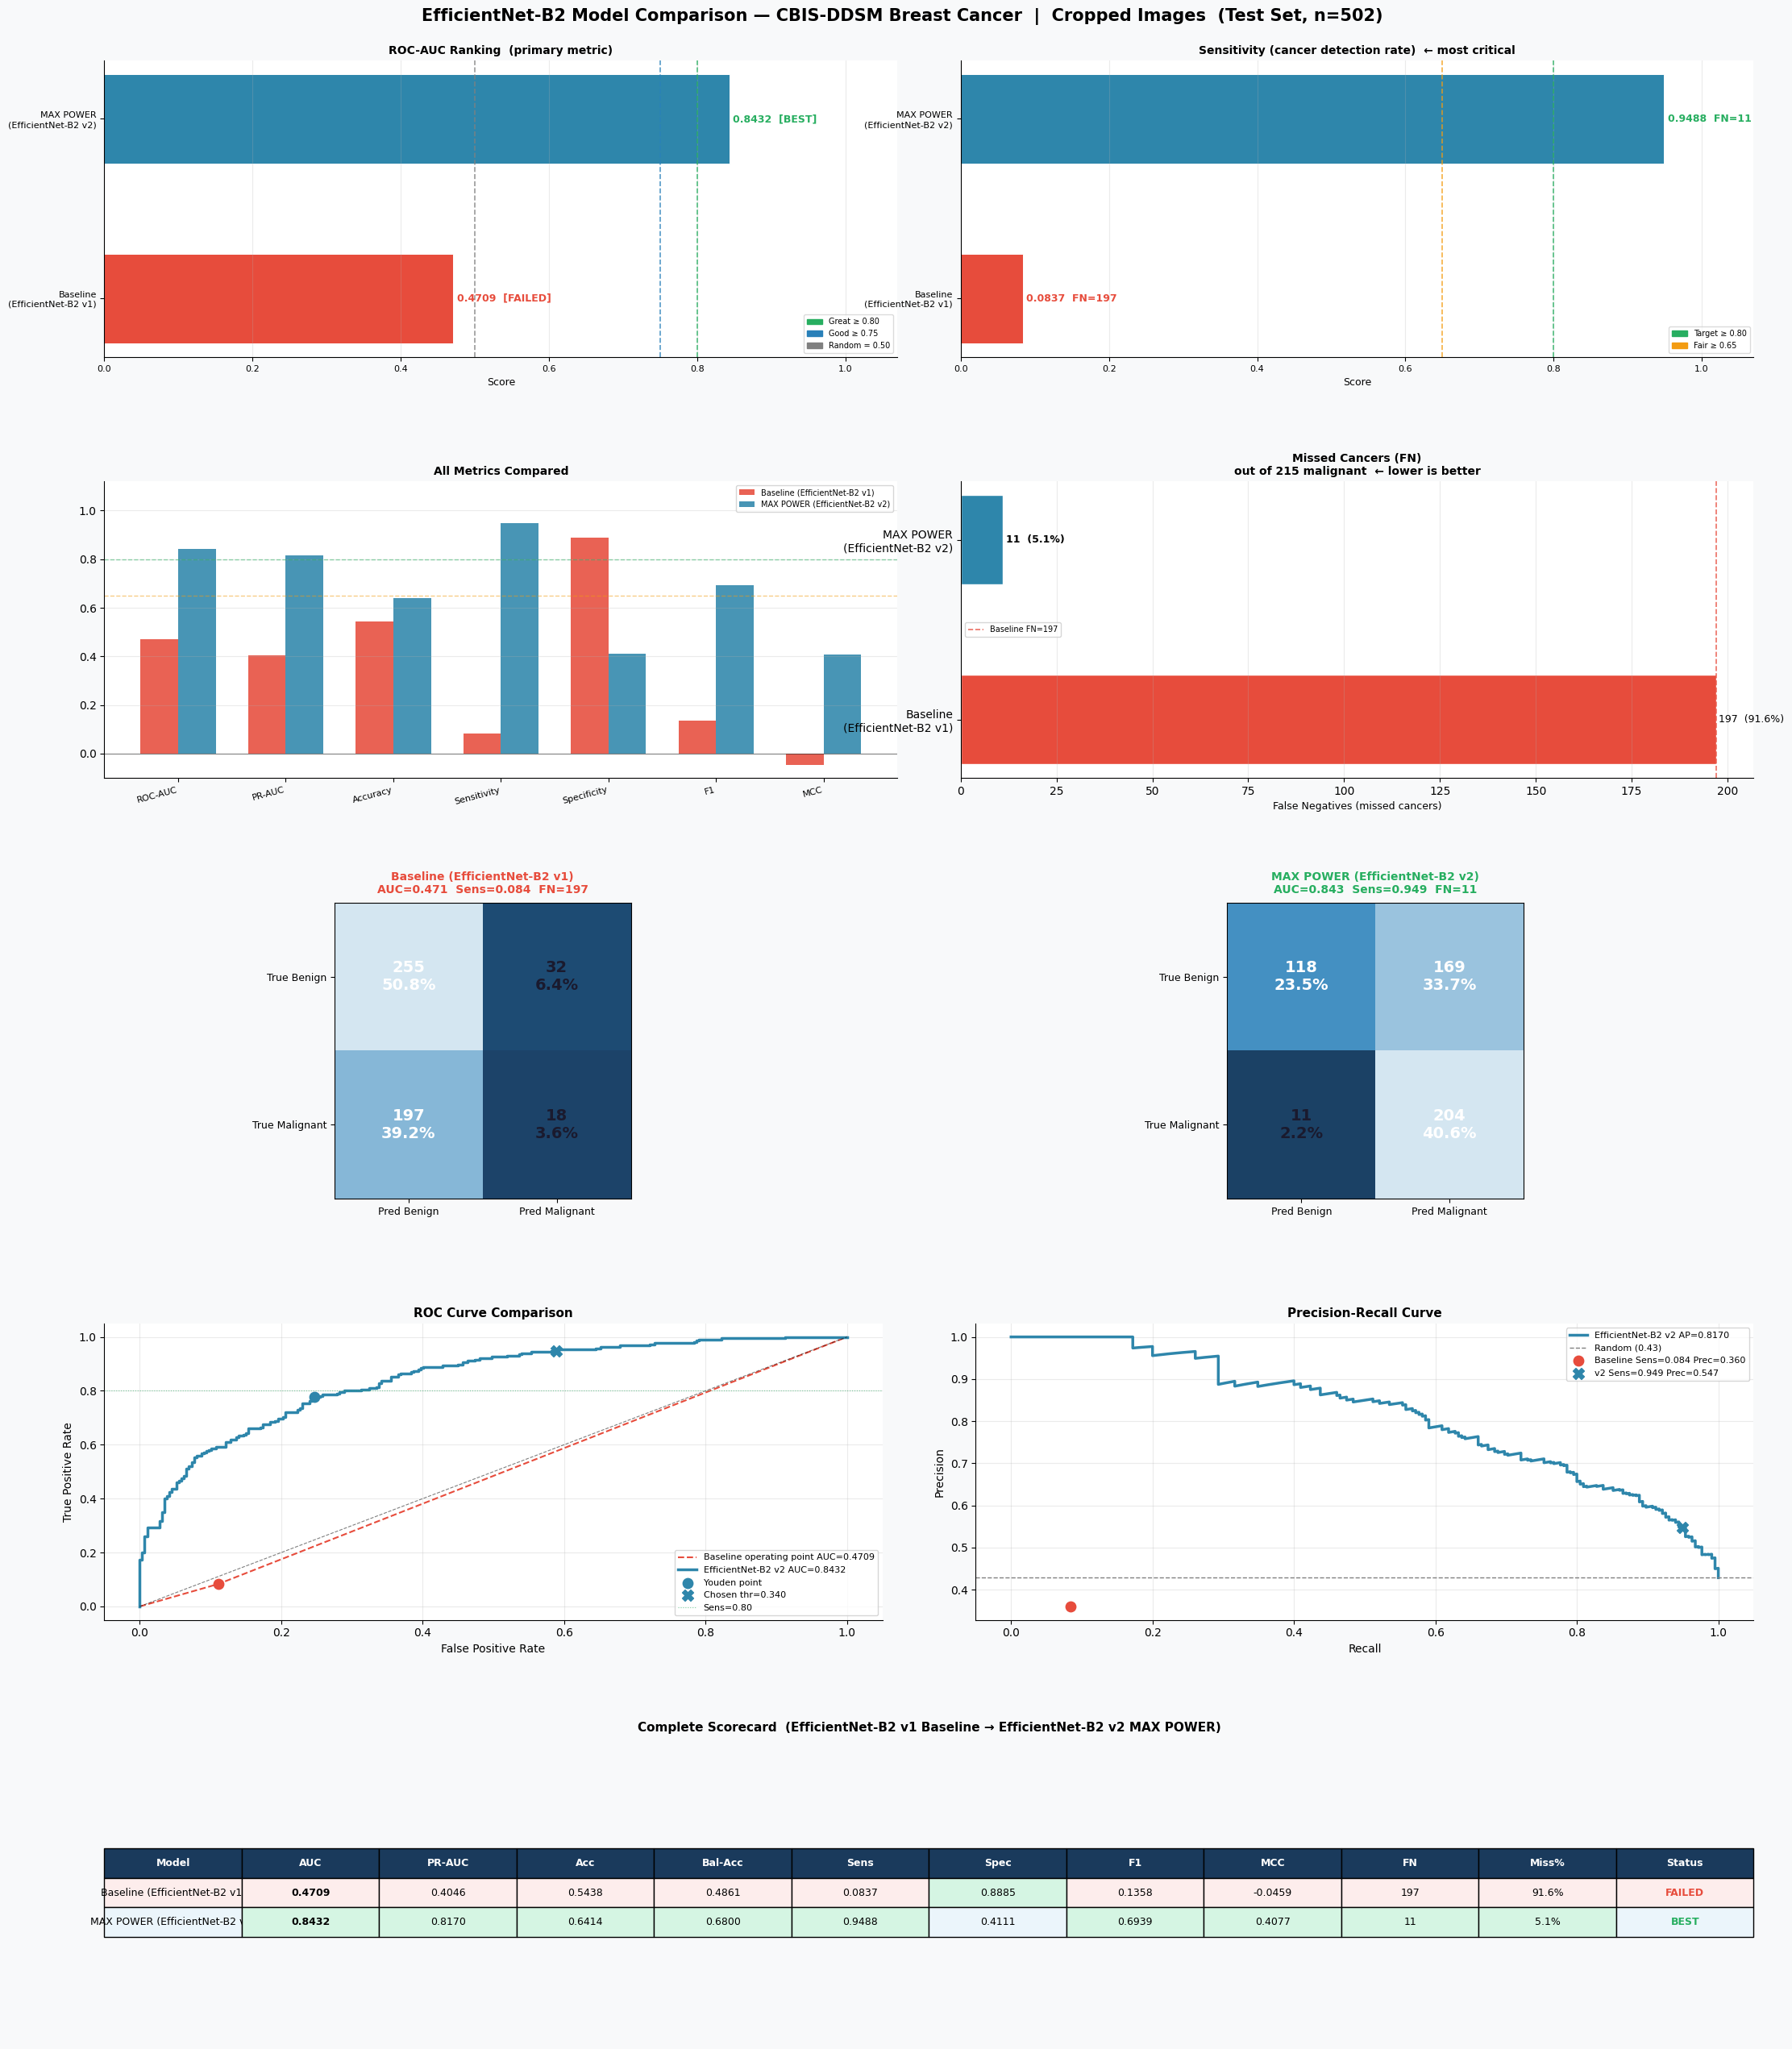

✅ EfficientNet-B2 comparison dashboard saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/efficientnet_b2_v2/efficientnet_b2_comparison_dashboard.png


In [26]:
# ============================================================================
# CELL 18 - EfficientNet-B2 Comprehensive Comparison Dashboard
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
)

# ── Safety check ─────────────────────────────────────────────────────────────
_required = ["y_true", "y_prob", "auc_roc", "ap", "SAVE_DIR"]
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        "Run the EfficientNet-B2 test evaluation cells first. "
        f"Missing variables: {_missing}"
    )

if "OPTIMAL_THRESHOLD" not in globals():
    print("⚠️ OPTIMAL_THRESHOLD not found. Using threshold=0.50.")
    OPTIMAL_THRESHOLD = 0.50

# ── Helpers ─────────────────────────────────────────────────────────────────
def status_color(auc):
    if auc >= 0.80:
        return "#27AE60"
    if auc >= 0.75:
        return "#2980B9"
    if auc >= 0.65:
        return "#F39C12"
    return "#E74C3C"

def status_label(auc):
    if auc >= 0.80:
        return "GREAT"
    if auc >= 0.75:
        return "GOOD"
    if auc >= 0.65:
        return "FAIR"
    return "FAILED"

def clean_ax(ax, axis="both"):
    ax.grid(axis=axis, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

def safe_div(a, b):
    return 0.0 if b == 0 else a / b

# ── Current EfficientNet-B2 v2 metrics from live notebook arrays ─────────────
y_true_dash = np.asarray(y_true).astype(int)
y_prob_dash = np.asarray(y_prob).astype(float)
y_pred_dash = (y_prob_dash >= float(OPTIMAL_THRESHOLD)).astype(int)

cm_new = confusion_matrix(y_true_dash, y_pred_dash, labels=[0, 1])
_tn, _fp, _fn, _tp = [int(x) for x in cm_new.ravel()]

_acc  = safe_div(_tp + _tn, _tp + _tn + _fp + _fn)
_sens = safe_div(_tp, _tp + _fn)
_spec = safe_div(_tn, _tn + _fp)
_prec = safe_div(_tp, _tp + _fp)
_f1   = f1_score(y_true_dash, y_pred_dash, zero_division=0)
_mcc  = matthews_corrcoef(y_true_dash, y_pred_dash) if len(set(y_pred_dash)) > 1 else 0.0
_bal  = balanced_accuracy_score(y_true_dash, y_pred_dash)
_auc  = roc_auc_score(y_true_dash, y_prob_dash)
_ap   = average_precision_score(y_true_dash, y_prob_dash)

# ── Model registry ───────────────────────────────────────────────────────────
# Baseline EfficientNet-B2 v1 values from uploaded 6-model final comparison:
# AUC=.4709, PR-AUC=.4046, Acc=.5438, Sens=.0837, Spec=.8885,
# F1=.1358, MCC=-.0459, TN=255, FP=32, FN=197, TP=18.
_b_tp, _b_tn, _b_fp, _b_fn = 18, 255, 32, 197

MODELS = {
    "Baseline\n(EfficientNet-B2 v1)": dict(
        color="#E74C3C",
        auc=0.4709,
        pr_auc=0.4046,
        acc=0.5438,
        sens=0.0837,
        spec=0.8885,
        prec=_b_tp / (_b_tp + _b_fp),
        f1=0.1358,
        mcc=-0.0459,
        fn=_b_fn,
        tp=_b_tp,
        tn=_b_tn,
        fp=_b_fp,
        n_mal=_b_tp + _b_fn,
        thr=None,
    ),
    "MAX POWER\n(EfficientNet-B2 v2)": dict(
        color="#2E86AB",
        auc=float(_auc),
        pr_auc=float(_ap),
        acc=float(_acc),
        sens=float(_sens),
        spec=float(_spec),
        prec=float(_prec),
        f1=float(_f1),
        mcc=float(_mcc),
        fn=int(_fn),
        tp=int(_tp),
        tn=int(_tn),
        fp=int(_fp),
        n_mal=int(_tp + _fn),
        thr=float(OPTIMAL_THRESHOLD),
    ),
}

names = list(MODELS.keys())
colors = [MODELS[n]["color"] for n in names]
best_auc_name = max(names, key=lambda n: MODELS[n]["auc"])

def display_status(nm):
    return "BEST" if nm == best_auc_name else status_label(MODELS[nm]["auc"])

n_test_total = _tp + _tn + _fp + _fn
n_malignant = _tp + _fn

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor="#F8F9FA")
fig.suptitle(
    f"EfficientNet-B2 Model Comparison — CBIS-DDSM Breast Cancer  |  Cropped Images"
    f"  (Test Set, n={n_test_total})",
    fontsize=15,
    fontweight="bold",
    y=0.99,
)

outer = gridspec.GridSpec(
    5, 1,
    figure=fig,
    hspace=0.42,
    top=0.965,
    bottom=0.02,
    left=0.05,
    right=0.98,
)

# ── ROW 0: AUC ranking | sensitivity ranking ────────────────────────────────
row0 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], wspace=0.08)
ax_auc = fig.add_subplot(row0[0])
ax_sens = fig.add_subplot(row0[1])

rank_auc = sorted(names, key=lambda n: MODELS[n]["auc"], reverse=True)
rank_sens = sorted(names, key=lambda n: MODELS[n]["sens"], reverse=True)

for ax, metric, order, title, reflines in [
    (
        ax_auc,
        "auc",
        rank_auc,
        "ROC-AUC Ranking  (primary metric)",
        [
            (0.80, "#27AE60", "Great ≥ 0.80"),
            (0.75, "#2980B9", "Good ≥ 0.75"),
            (0.50, "gray", "Random = 0.50"),
        ],
    ),
    (
        ax_sens,
        "sens",
        rank_sens,
        "Sensitivity (cancer detection rate)  ← most critical",
        [
            (0.80, "#27AE60", "Target ≥ 0.80"),
            (0.65, "#F39C12", "Fair ≥ 0.65"),
        ],
    ),
]:
    vals = [MODELS[n][metric] for n in order]
    cols = [MODELS[n]["color"] for n in order]

    bars = ax.barh(order, vals, color=cols, height=0.5, edgecolor="white", linewidth=0.7)
    ax.invert_yaxis()

    for bar, val, nm in zip(bars, vals, order):
        sc = status_color(MODELS[nm]["auc"])
        label = (
            f"{val:.4f}  [{display_status(nm)}]"
            if metric == "auc"
            else f"{val:.4f}  FN={MODELS[nm]['fn']}"
        )
        ax.text(
            val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=9,
            color=sc,
            fontweight="bold",
        )

    for xv, c, lbl in reflines:
        ax.axvline(xv, color=c, ls="--", lw=1.2, alpha=0.8)

    ax.set_xlim(0, 1.07)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.tick_params(labelsize=8)
    ax.set_xlabel("Score", fontsize=9)
    clean_ax(ax, axis="x")

    handles = [mpatches.Patch(color=c, label=lbl) for _, c, lbl in reflines]
    ax.legend(handles=handles, fontsize=7, loc="lower right", framealpha=0.7)

# ── ROW 1: all metrics | missed cancers ─────────────────────────────────────
row1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], wspace=0.08)
ax_multi = fig.add_subplot(row1[0])
ax_fn = fig.add_subplot(row1[1])

MK = ["auc", "pr_auc", "acc", "sens", "spec", "f1", "mcc"]
MLBL = ["ROC-AUC", "PR-AUC", "Accuracy", "Sensitivity", "Specificity", "F1", "MCC"]

x = np.arange(len(MK))
bw = 0.35

for i, nm in enumerate(names):
    vals = [MODELS[nm][k] for k in MK]
    ax_multi.bar(
        x + (i - 0.5) * bw,
        vals,
        bw,
        color=MODELS[nm]["color"],
        alpha=0.88,
        label=nm.replace("\n", " "),
    )

all_vals = [MODELS[nm][k] for nm in names for k in MK]
ax_multi.set_xticks(x)
ax_multi.set_xticklabels(MLBL, rotation=15, ha="right", fontsize=8)
ax_multi.set_ylim(min(-0.10, min(all_vals) - 0.05), 1.12)
ax_multi.axhline(0.00, color="black", lw=0.8, alpha=0.45)
ax_multi.axhline(0.80, color="#27AE60", ls="--", lw=1, alpha=0.5)
ax_multi.axhline(0.65, color="#F39C12", ls="--", lw=1, alpha=0.5)
ax_multi.set_title("All Metrics Compared", fontsize=10, fontweight="bold")
ax_multi.legend(fontsize=7, loc="upper right")
clean_ax(ax_multi, axis="y")

rank_fn = sorted(names, key=lambda n: MODELS[n]["fn"])
fn_vals = [MODELS[n]["fn"] for n in rank_fn]
fn_cols = [MODELS[n]["color"] for n in rank_fn]

fn_bars = ax_fn.barh(rank_fn, fn_vals, color=fn_cols, height=0.5, edgecolor="white")
ax_fn.invert_yaxis()

for bar, fn, nm in zip(fn_bars, fn_vals, rank_fn):
    n_mal = MODELS[nm]["n_mal"]
    ax_fn.text(
        fn + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{fn}  ({fn / n_mal * 100:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold" if "v2" in nm else "normal",
    )

ax_fn.axvline(
    _b_fn,
    color=MODELS["Baseline\n(EfficientNet-B2 v1)"]["color"],
    ls="--",
    lw=1.2,
    alpha=0.8,
    label=f"Baseline FN={_b_fn}",
)
ax_fn.set_title(
    f"Missed Cancers (FN)\nout of {n_malignant} malignant  ← lower is better",
    fontsize=10,
    fontweight="bold",
)
ax_fn.set_xlabel("False Negatives (missed cancers)", fontsize=9)
ax_fn.legend(fontsize=7)
clean_ax(ax_fn, axis="x")

# ── ROW 2: confusion matrices ───────────────────────────────────────────────
row2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[2], wspace=0.18)
cmap_cm = LinearSegmentedColormap.from_list(
    "cm_dashboard",
    ["#1A3A5C", "#2980B9", "#D4E6F1"],
)

for i, nm in enumerate(names):
    d = MODELS[nm]
    cm_arr = np.array([[d["tn"], d["fp"]], [d["fn"], d["tp"]]])
    n = cm_arr.sum()

    ax = fig.add_subplot(row2[i])
    ax.imshow(cm_arr, cmap=cmap_cm, vmin=0, vmax=max(cm_arr.max(), 1))

    for r in range(2):
        for c in range(2):
            val = cm_arr[r, c]
            ax.text(
                c,
                r,
                f"{val}\n{val / n * 100:.1f}%",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color="white" if val > cm_arr.max() * 0.4 else "#1A1A2E",
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Benign", "Pred Malignant"], fontsize=9)
    ax.set_yticklabels(["True Benign", "True Malignant"], fontsize=9)
    ax.set_title(
        f"{nm.replace(chr(10), ' ')}\n"
        f"AUC={d['auc']:.3f}  Sens={d['sens']:.3f}  FN={d['fn']}",
        fontsize=10,
        fontweight="bold",
        color=status_color(d["auc"]),
        pad=8,
    )

# ── ROW 3: ROC and PR curves ────────────────────────────────────────────────
row3 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[3], wspace=0.12)
ax_roc = fig.add_subplot(row3[0])
ax_pr = fig.add_subplot(row3[1])

fpr_new, tpr_new, thr_new = roc_curve(y_true_dash, y_prob_dash)
youden_idx = int(np.argmax(tpr_new - fpr_new))

pr_precision, pr_recall, _ = precision_recall_curve(y_true_dash, y_prob_dash)
random_pr = y_true_dash.mean()

b = MODELS["Baseline\n(EfficientNet-B2 v1)"]
n = MODELS["MAX POWER\n(EfficientNet-B2 v2)"]

# Baseline raw probabilities are not available from the image,
# so this is an operating-point proxy using the baseline confusion matrix.
ax_roc.plot(
    [0, 1 - b["spec"], 1],
    [0, b["sens"], 1],
    "--",
    color=b["color"],
    lw=1.5,
    label=f"Baseline operating point AUC={b['auc']:.4f}",
)
ax_roc.scatter(
    [1 - b["spec"]],
    [b["sens"]],
    color=b["color"],
    s=80,
    zorder=5,
)

ax_roc.plot(
    fpr_new,
    tpr_new,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"EfficientNet-B2 v2 AUC={n['auc']:.4f}",
)
ax_roc.scatter(
    [fpr_new[youden_idx]],
    [tpr_new[youden_idx]],
    color=n["color"],
    s=80,
    zorder=5,
    label="Youden point",
)
ax_roc.scatter(
    [1 - n["spec"]],
    [n["sens"]],
    marker="X",
    color=n["color"],
    s=100,
    zorder=6,
    label=f"Chosen thr={n['thr']:.3f}",
)

ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax_roc.axhline(0.80, color="#27AE60", ls=":", lw=0.8, alpha=0.6, label="Sens=0.80")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve Comparison", fontsize=11, fontweight="bold")
ax_roc.legend(fontsize=8)
clean_ax(ax_roc)

ax_pr.plot(
    pr_recall,
    pr_precision,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"EfficientNet-B2 v2 AP={n['pr_auc']:.4f}",
)
ax_pr.axhline(random_pr, color="gray", ls="--", lw=1, label=f"Random ({random_pr:.2f})")

ax_pr.scatter(
    [b["sens"]],
    [b["prec"]],
    color=b["color"],
    s=80,
    zorder=5,
    label=f"Baseline Sens={b['sens']:.3f} Prec={b['prec']:.3f}",
)
ax_pr.scatter(
    [n["sens"]],
    [n["prec"]],
    color=n["color"],
    marker="X",
    s=100,
    zorder=6,
    label=f"v2 Sens={n['sens']:.3f} Prec={n['prec']:.3f}",
)

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
ax_pr.legend(fontsize=8)
clean_ax(ax_pr)

# ── ROW 4: scorecard table ─────────────────────────────────────────────────
ax_tbl = fig.add_subplot(outer[4])
ax_tbl.axis("off")

COLS = [
    "Model",
    "AUC",
    "PR-AUC",
    "Acc",
    "Bal-Acc",
    "Sens",
    "Spec",
    "F1",
    "MCC",
    "FN",
    "Miss%",
    "Status",
]

rows_data = []
for nm in names:
    d = MODELS[nm]
    bal_acc = (d["sens"] + d["spec"]) / 2
    rows_data.append([
        nm.replace("\n", " "),
        f"{d['auc']:.4f}",
        f"{d['pr_auc']:.4f}",
        f"{d['acc']:.4f}",
        f"{bal_acc:.4f}",
        f"{d['sens']:.4f}",
        f"{d['spec']:.4f}",
        f"{d['f1']:.4f}",
        f"{d['mcc']:.4f}",
        str(d["fn"]),
        f"{d['fn'] / d['n_mal'] * 100:.1f}%",
        display_status(nm),
    ])

tbl = ax_tbl.table(cellText=rows_data, colLabels=COLS, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 2.2)

# Header
for j in range(len(COLS)):
    tbl[(0, j)].set_facecolor("#1A3A5C")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")

row_bg = ["#FDEDEC", "#EBF5FB"]
for i, nm in enumerate(names):
    sc = status_color(MODELS[nm]["auc"])
    for j in range(len(COLS)):
        cell = tbl[(i + 1, j)]
        cell.set_facecolor(row_bg[i])
        if j == 1:
            cell.set_text_props(fontweight="bold")
        if j == len(COLS) - 1:
            cell.set_text_props(color=sc, fontweight="bold")

# Highlight winners
higher_is_better = {1, 2, 3, 4, 5, 6, 7, 8}
lower_is_better = {9, 10}

for col_idx in range(1, len(COLS) - 1):
    raw = []
    for r in range(len(names)):
        txt = tbl[(r + 1, col_idx)].get_text().get_text().replace("%", "")
        raw.append(float(txt))

    if col_idx in higher_is_better:
        best_val = max(raw)
    elif col_idx in lower_is_better:
        best_val = min(raw)
    else:
        continue

    for r, val in enumerate(raw):
        if abs(val - best_val) < 1e-9:
            tbl[(r + 1, col_idx)].set_facecolor("#D5F5E3")

ax_tbl.set_title(
    "Complete Scorecard  (EfficientNet-B2 v1 Baseline → EfficientNet-B2 v2 MAX POWER)",
    fontsize=11,
    fontweight="bold",
    pad=12,
    y=1.0,
)

# ── Save ────────────────────────────────────────────────────────────────────
save_path = Path(SAVE_DIR) / "efficientnet_b2_comparison_dashboard.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.show()

print(f"✅ EfficientNet-B2 comparison dashboard saved → {save_path}")